# DSAI 4103 — Business Analytics Project
## Notebook 02: Feature Engineering
**Input:**  `data/processed/diabetic_cleaned.csv`  
**Output:** `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Objective:** Encode categoricals, engineer new features, and prepare train/test splits for AutoML.

---
## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/Course_Project/'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs(BASE + 'data/processed', exist_ok=True)
os.makedirs(BASE + 'models', exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Cleaned Dataset

In [ ]:
df = pd.read_csv(BASE + 'data/processed/diabetic_cleaned.csv')

print(f'Shape: {df.shape}')
print(f'Target distribution:')
print(df['readmitted_binary'].value_counts())
df.head(3)

Shape: (69973, 54)
Target distribution:
readmitted_binary
0    63696
1     6277
Name: count, dtype: int64


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,change,diabetesMed,readmitted,admission_type_desc,discharge_disposition_desc,admission_source_desc,readmitted_binary,readmit_label,med_bin,diag1_group
0,12522,48330783,Caucasian,Female,[80-90),2,1,4,13,NaN,...,Ch,Yes,NO,Urgent,Discharged to home,Transfer from a hospital,0,Not Readmitted <30d,25+,Circulatory
1,15738,63555939,Caucasian,Female,[90-100),3,3,4,12,NaN,...,Ch,Yes,NO,Elective,Discharged/transferred to SNF,Transfer from a hospital,0,Not Readmitted <30d,16-20,Circulatory
2,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,...,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room,0,Not Readmitted <30d,6-10,Neoplasms


---
## 2. Drop Non-Feature Columns

In [ ]:
# Columns to drop — identifiers, redundant, or target-leaking
drop_cols = [
    'encounter_id',           # identifier
    'patient_nbr',            # identifier
    'readmitted',             # original target (replaced by binary)
    'readmit_label',          # string version of target
    'med_bin',                # derived bin from EDA — not a model feature
    'admission_type_desc',    # human-readable duplicate of admission_type_id
    'discharge_disposition_desc', # human-readable duplicate
    'admission_source_desc',  # human-readable duplicate
    'diag1_group',            # derived in EDA only
]

# Only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

print(f'Shape after dropping non-features: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

Shape after dropping non-features: (69973, 45)
Remaining columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_binary']


---
## 3. Feature Engineering — Create New Features

In [ ]:
# 3.1  Drug columns list
drug_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
drug_cols = [c for c in drug_cols if c in df.columns]

# 3.2  num_changed: count of drugs where dosage was changed (Up or Down)
df['num_changed'] = (df[drug_cols].isin(['Up', 'Down'])).sum(axis=1)
print(f'num_changed  — mean: {df["num_changed"].mean():.2f}, max: {df["num_changed"].max()}')

# 3.3  num_on_drug: count of drugs actually prescribed (not "No")
df['num_on_drug'] = (df[drug_cols] != 'No').sum(axis=1)
print(f'num_on_drug  — mean: {df["num_on_drug"].mean():.2f}, max: {df["num_on_drug"].max()}')

# 3.4  total_visits: all prior healthcare visits combined
df['total_visits'] = (df['number_outpatient'] +
                      df['number_inpatient'] +
                      df['number_emergency'])
print(f'total_visits — mean: {df["total_visits"].mean():.2f}, max: {df["total_visits"].max()}')

# 3.5  high_utilizer: flag patients with many prior inpatient visits
df['high_utilizer'] = (df['number_inpatient'] >= 2).astype(int)
print(f'high_utilizer — {df["high_utilizer"].sum():,} patients ({df["high_utilizer"].mean()*100:.1f}%)')

# 3.6  diabetes_primary_diag: flag if primary diagnosis is diabetes
df['diabetes_primary_diag'] = df['diag_1'].astype(str).str.startswith('250').astype(int)
print(f'diabetes_primary_diag — {df["diabetes_primary_diag"].sum():,} patients ({df["diabetes_primary_diag"].mean()*100:.1f}%)')

# 3.7  insulin_flag: patient is on insulin
df['insulin_flag'] = (df['insulin'] != 'No').astype(int)
print(f'insulin_flag  — {df["insulin_flag"].sum():,} patients ({df["insulin_flag"].mean()*100:.1f}%)')

print('\nAll engineered features created successfully.')

num_changed  — mean: 0.26, max: 4
num_on_drug  — mean: 1.19, max: 6
total_visits — mean: 0.56, max: 49
high_utilizer — 2,397 patients (3.4%)
diabetes_primary_diag — 5,748 patients (8.2%)
insulin_flag  — 35,715 patients (51.0%)

All engineered features created successfully.


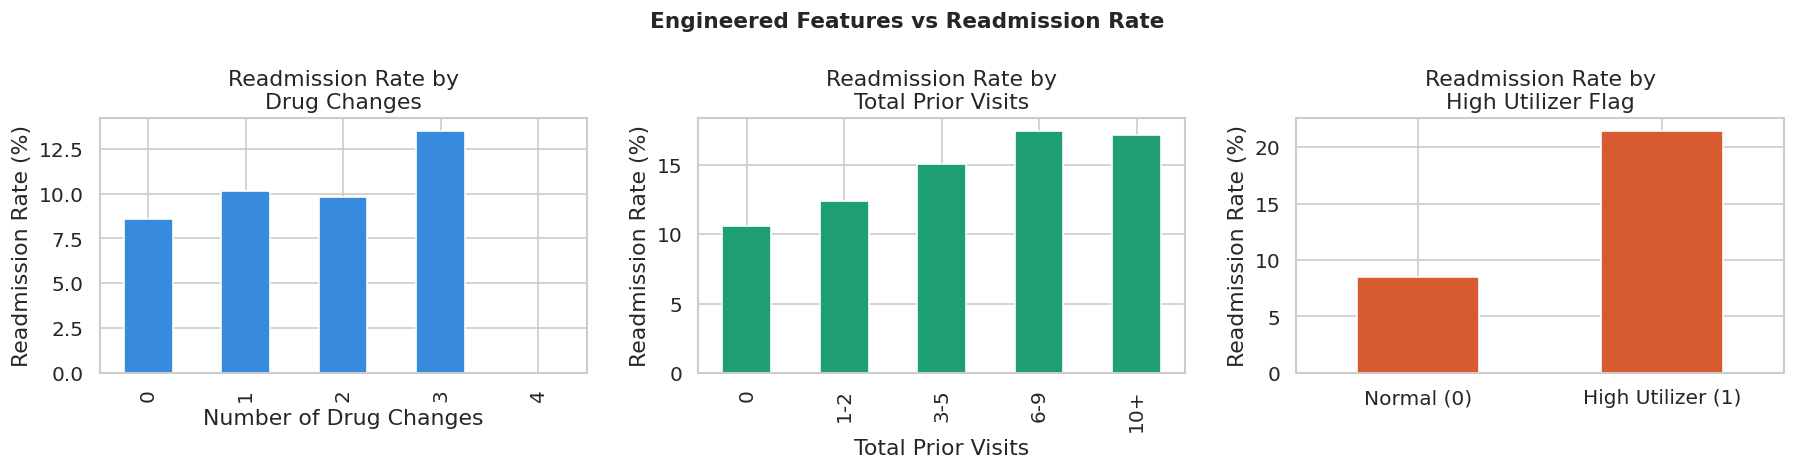

Saved: outputs/figures/09_engineered_features.png


In [ ]:
# Visualise engineered features vs readmission
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# num_changed
df.groupby('num_changed')['readmitted_binary'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='#378ADD', edgecolor='white')
axes[0].set_title('Readmission Rate by\nDrug Changes')
axes[0].set_xlabel('Number of Drug Changes')
axes[0].set_ylabel('Readmission Rate (%)')

# total_visits
visit_bins = pd.cut(df['total_visits'], bins=[0,1,3,6,10,100],
                    labels=['0','1-2','3-5','6-9','10+'])
visit_rate = df.groupby(visit_bins)['readmitted_binary'].mean().mul(100)
visit_rate.plot(kind='bar', ax=axes[1], color='#1D9E75', edgecolor='white')
axes[1].set_title('Readmission Rate by\nTotal Prior Visits')
axes[1].set_xlabel('Total Prior Visits')
axes[1].set_ylabel('Readmission Rate (%)')

# high_utilizer
df.groupby('high_utilizer')['readmitted_binary'].mean().mul(100).plot(
    kind='bar', ax=axes[2], color='#D85A30', edgecolor='white')
axes[2].set_xticklabels(['Normal (0)', 'High Utilizer (1)'], rotation=0)
axes[2].set_title('Readmission Rate by\nHigh Utilizer Flag')
axes[2].set_xlabel('')
axes[2].set_ylabel('Readmission Rate (%)')

plt.suptitle('Engineered Features vs Readmission Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/09_engineered_features.png')
plt.show()
print('Saved: outputs/figures/09_engineered_features.png')

---
## 4. Encode Categorical Features

In [ ]:
# 4.1  Age: ordinal encoding (bracket → integer 0–9)
age_map = {
    '[0-10)':1, '[10-20)':2, '[20-30)':3, '[30-40)':4, '[40-50)':5,
    '[50-60)':6, '[60-70)':7, '[70-80)':8, '[80-90)':9, '[90-100)':10
}
df['age_encoded'] = df['age'].map(age_map)
print('Age encoded:', df['age_encoded'].value_counts().sort_index().to_dict())

Age encoded: {1: 153, 2: 534, 3: 1121, 4: 2692, 5: 6828, 6: 12349, 7: 15684, 8: 17750, 9: 11102, 10: 1760}


In [ ]:
# 4.2  Drug columns: ordinal encoding (No=0, Steady=1, Up=2, Down=3)
drug_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
for col in drug_cols:
    df[col + '_enc'] = df[col].map(drug_map).fillna(0).astype(int)

drug_enc_cols = [c + '_enc' for c in drug_cols]
print(f'Drug columns encoded: {len(drug_enc_cols)} columns')

Drug columns encoded: 23 columns


In [ ]:
# 4.3  Binary categoricals
df['gender_enc']       = (df['gender'] == 'Male').astype(int)
df['change_enc']       = (df['change'] == 'Ch').astype(int)
df['diabetesMed_enc']  = (df['diabetesMed'] == 'Yes').astype(int)
print('Binary columns encoded: gender_enc, change_enc, diabetesMed_enc')

Binary columns encoded: gender_enc, change_enc, diabetesMed_enc


In [ ]:
# 4.4  Race: one-hot encoding
race_dummies = pd.get_dummies(df['race'], prefix='race', drop_first=True)
df = pd.concat([df, race_dummies], axis=1)
race_cols = race_dummies.columns.tolist()
print(f'Race one-hot columns: {race_cols}')

Race one-hot columns: ['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown']


In [ ]:
# 4.5  Diagnosis columns: label encode (high cardinality)
le = LabelEncoder()
for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    df[diag_col] = df[diag_col].astype(str).fillna('Unknown')
    df[diag_col + '_enc'] = le.fit_transform(df[diag_col])

print('Diagnosis columns label-encoded: diag_1_enc, diag_2_enc, diag_3_enc')

Diagnosis columns label-encoded: diag_1_enc, diag_2_enc, diag_3_enc


In [ ]:
# 4.6  Medical specialty: label encode
df['medical_specialty'] = df['medical_specialty'].fillna('Missing')
df['medical_specialty_enc'] = le.fit_transform(df['medical_specialty'].astype(str))
print(f'Medical specialty: {df["medical_specialty"].nunique()} unique values encoded')

Medical specialty: 71 unique values encoded


---
## 5. Build Final Feature Matrix

In [ ]:
# Select final feature columns for model
numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
]

engineered_features = [
    'num_changed', 'num_on_drug', 'total_visits',
    'high_utilizer', 'diabetes_primary_diag', 'insulin_flag'
]

encoded_features = (
    ['age_encoded', 'gender_enc', 'change_enc', 'diabetesMed_enc',
     'medical_specialty_enc', 'diag_1_enc', 'diag_2_enc', 'diag_3_enc']
    + drug_enc_cols
    + race_cols
)

all_features = numeric_features + engineered_features + encoded_features

# Keep only columns that exist
all_features = [f for f in all_features if f in df.columns]

print(f'Total features selected: {len(all_features)}')
print(f'  Numeric    : {len(numeric_features)}')
print(f'  Engineered : {len(engineered_features)}')
print(f'  Encoded    : {len([f for f in encoded_features if f in df.columns])}')

Total features selected: 53
  Numeric    : 11
  Engineered : 6
  Encoded    : 36


In [ ]:
X = df[all_features].copy()
y = df['readmitted_binary'].copy()

# Sanity checks
print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Missing in X: {X.isnull().sum().sum()}')
print(f'\nTarget distribution:')
print(y.value_counts())
print(f'Class imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1')

X shape : (69973, 53)
y shape : (69973,)
Missing in X: 0

Target distribution:
readmitted_binary
0    63696
1     6277
Name: count, dtype: int64
Class imbalance ratio: 10.1:1


---
## 6. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class ratio in both splits
)

print(f'Train size : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test size  : {X_test.shape[0]:,}  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTrain target distribution:')
print(y_train.value_counts())
print(f'\nTest target distribution:')
print(y_test.value_counts())

Train size : 55,978 (80%)
Test size  : 13,995  (20%)

Train target distribution:
readmitted_binary
0    50956
1     5022
Name: count, dtype: int64

Test target distribution:
readmitted_binary
0    12740
1     1255
Name: count, dtype: int64


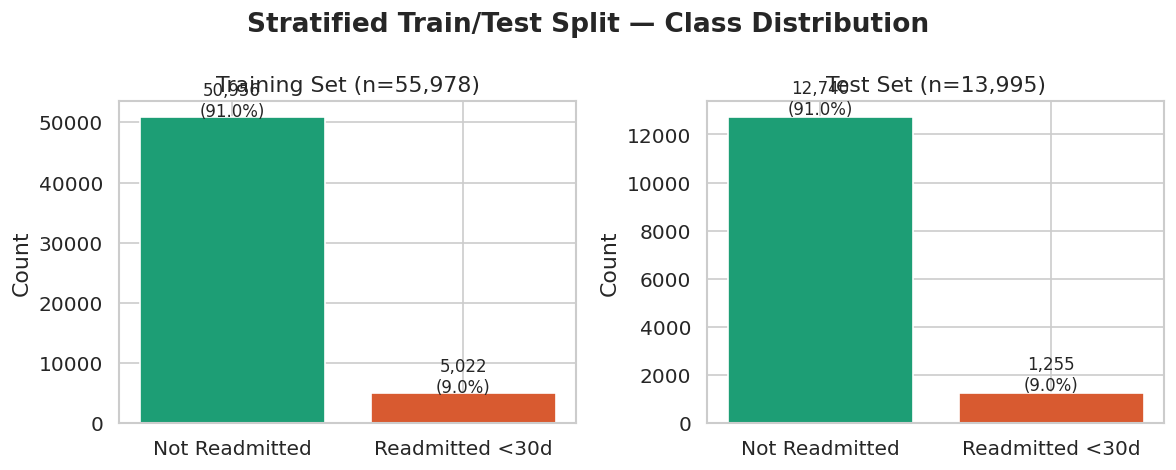

In [ ]:
# Visualise train/test split
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_data, title in zip(
    axes,
    [y_train, y_test],
    ['Training Set', 'Test Set']
):
    counts = y_data.value_counts()
    ax.bar(['Not Readmitted', 'Readmitted <30d'],
           counts.values,
           color=['#1D9E75', '#D85A30'],
           edgecolor='white')
    ax.set_title(f'{title} (n={len(y_data):,})')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}\n({v/len(y_data)*100:.1f}%)',
                ha='center', fontsize=10)

plt.suptitle('Stratified Train/Test Split — Class Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/10_train_test_split.png')
plt.show()

---
## 7. Save All Outputs

In [ ]:
# Save train/test splits as CSV
X_train.to_csv(BASE + 'data/processed/X_train.csv', index=False)
X_test.to_csv(BASE + 'data/processed/X_test.csv',  index=False)
y_train.to_csv(BASE + 'data/processed/y_train.csv', index=False)
y_test.to_csv(BASE + 'data/processed/y_test.csv',  index=False)

# Save feature names list for scoring script
with open(BASE + 'models/feature_names.pkl', 'wb') as f:
    pickle.dump(all_features, f)

# Save full engineered dataset
df[all_features + ['readmitted_binary']].to_csv(
    BASE + 'data/processed/diabetic_features.csv', index=False)

print('All outputs saved:')
print(f'  data/processed/X_train.csv         {X_train.shape}')
print(f'  data/processed/X_test.csv          {X_test.shape}')
print(f'  data/processed/y_train.csv         {y_train.shape}')
print(f'  data/processed/y_test.csv          {y_test.shape}')
print(f'  data/processed/diabetic_features.csv')
print(f'  models/feature_names.pkl')

All outputs saved:
  data/processed/X_train.csv         (55978, 53)
  data/processed/X_test.csv          (13995, 53)
  data/processed/y_train.csv         (55978,)
  data/processed/y_test.csv          (13995,)
  data/processed/diabetic_features.csv
  models/feature_names.pkl


---
## 8. Feature Engineering Summary

In [ ]:
print('=' * 55)
print('     FEATURE ENGINEERING SUMMARY')
print('=' * 55)
print(f'Input rows              : {len(df):>10,}')
print(f'Total features          : {len(all_features):>10}')
print(f'  Original numeric      : {len(numeric_features):>10}')
print(f'  Engineered (new)      : {len(engineered_features):>10}')
print(f'  Encoded categoricals  : {len([f for f in encoded_features if f in df.columns]):>10}')
print('-' * 55)
print(f'Train samples           : {len(X_train):>10,}')
print(f'Test samples            : {len(X_test):>10,}')
print(f'Missing values in X     : {X.isnull().sum().sum():>10}')
print('-' * 55)
print('Engineered features created:')
print('  num_changed         — drugs with dosage changes')
print('  num_on_drug         — total drugs prescribed')
print('  total_visits        — sum of all prior visits')
print('  high_utilizer       — flag: ≥2 prior inpatient visits')
print('  diabetes_primary_diag — flag: primary diag is diabetes')
print('  insulin_flag        — flag: patient on insulin')
print('=' * 55)
print('Next step → 03_model_training.ipynb')

     FEATURE ENGINEERING SUMMARY
Input rows              :     69,973
Total features          :         53
  Original numeric      :         11
  Engineered (new)      :          6
  Encoded categoricals  :         36
-------------------------------------------------------
Train samples           :     55,978
Test samples            :     13,995
Missing values in X     :          0
-------------------------------------------------------
Engineered features created:
  num_changed         — drugs with dosage changes
  num_on_drug         — total drugs prescribed
  total_visits        — sum of all prior visits
  high_utilizer       — flag: ≥2 prior inpatient visits
  diabetes_primary_diag — flag: primary diag is diabetes
  insulin_flag        — flag: patient on insulin
Next step → 03_model_training.ipynb
